In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("//content/healthcare_data_for_task.csv")

In [21]:
print(df.head)

<bound method NDFrame.head of     Patient_ID  Age  Gender Blood_Type Medical_Condition Medical_Code  \
0        P0001   47    Male        AB+     Heart Disease       HEA004   
1        P0002   62  Female        AB-          Diabetes       DIA001   
2        P0003   36    Male        AB-     Heart Disease       HEA004   
3        P0004   51    Male         A+     Heart Disease       HEA004   
4        P0005   30    Male         A+          Diabetes       DIA001   
..         ...  ...     ...        ...               ...          ...   
995      P0996   24  Female         A+          Diabetes       DIA001   
996      P0997   63  Female         O+          Diabetes       DIA001   
997      P0998   63  Female        AB+          Diabetes       DIA001   
998      P0999   33    Male         O-          Diabetes       DIA001   
999      P1000   41    Male         A-            Asthma       AST003   

    Date_of_Admission Discharge_Date Admission_Type  Billing_Amount  
0          2025-05-10  

In [22]:
print(df.shape)

(1000, 10)


In [23]:
print(df.columns)

Index(['Patient_ID', 'Age', 'Gender', 'Blood_Type', 'Medical_Condition',
       'Medical_Code', 'Date_of_Admission', 'Discharge_Date', 'Admission_Type',
       'Billing_Amount'],
      dtype='object')


In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         1000 non-null   object 
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   object 
 3   Blood_Type         1000 non-null   object 
 4   Medical_Condition  1000 non-null   object 
 5   Medical_Code       970 non-null    object 
 6   Date_of_Admission  1000 non-null   object 
 7   Discharge_Date     1000 non-null   object 
 8   Admission_Type     1000 non-null   object 
 9   Billing_Amount     1000 non-null   float64
dtypes: float64(1), int64(1), object(8)
memory usage: 78.3+ KB
None


In [25]:
df['Age']
df['Patient_ID']

,Patient_ID
0,P0001
1,P0002
2,P0003
3,P0004
4,P0005
...,...
995,P0996
996,P0997
997,P0998
998,P0999


In [26]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
Blood_Type,0
Medical_Condition,0
Medical_Code,30
Date_of_Admission,0
Discharge_Date,0
Admission_Type,0
Billing_Amount,0


In [27]:
df['Medical_Code']=df['Medical_Code'].fillna('unknown')

In [28]:
df['Admission_Type'] = (
    df['Admission_Type']
    .str.strip()
    .str.title()
)

In [29]:
df['Admission_Type'].unique()

array(['Emergency', 'Elective', 'Urgent'], dtype=object)

In [30]:
df['Admission_Type'].value_counts()

,count
Admission_Type,
Emergency,381
Elective,368
Urgent,251


In [31]:
df['Date_of_Admission']=pd.to_datetime(df['Date_of_Admission'])

In [32]:
df['Discharge_Date']=pd.to_datetime(df['Discharge_Date'])

In [33]:
df['Date_of_Admission'].dt.year

,Date_of_Admission
0,2025
1,2025
2,2025
3,2023
4,2024
...,...
995,2023
996,2025
997,2023
998,2023


In [34]:
df['Date_of_Admission'].dt.month

,Date_of_Admission
0,5
1,12
2,11
3,5
4,4
...,...
995,3
996,4
997,5
998,2


In [35]:
df['Date_of_Admission'].dt.day

,Date_of_Admission
0,10
1,31
2,10
3,2
4,11
...,...
995,16
996,17
997,8
998,11


In [36]:
df['Stay _Days']=(df['Discharge_Date']-df['Date_of_Admission']).dt.days

In [37]:
df['Billing_Amount'].describe()

,Billing_Amount
count,1000.000000
mean,77117.515720
std,41955.242269
min,5568.160000
25%,40318.785000
50%,77293.900000
75%,113089.267500
max,149921.800000


In [39]:
df.groupby('Medical_Condition')['Age'].mean()

,Age
Medical_Condition,
Arthritis,52.674641
Asthma,49.919598
Diabetes,53.130653
Heart Disease,52.180995
Hypertension,51.395349


In [41]:
pd.crosstab(
    df['Medical_Condition'],
    df['Gender']
)

Gender,Female,Male
Medical_Condition,,
Arthritis,95,114
Asthma,101,98
Diabetes,110,89
Heart Disease,104,117
Hypertension,80,92


<Axes: xlabel='Admission_Type'>

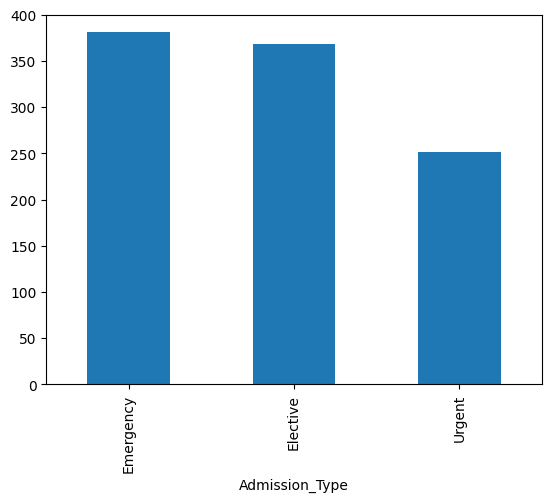

In [42]:
df['Admission_Type'].value_counts().plot(kind='bar')